# Churn SaaS — pipeline de données

Estimer la probabilité de résiliation d'un client à l'échéance, à partir de
`docs/churn_saas_complet.csv` (5035 lignes, 28 % de churn).

**Prérequis** : `docker compose up -d` — PostgreSQL sur le port 5432, pgAdmin sur
http://localhost:5050.

## 🥉🥈🥇 Ingestion complète

Lance les trois couches à la suite : `docs/*.csv` → 🥉 bronze → 🥈 silver →
🥇 gold. Chaque couche est intégralement rechargée, l'exécution est donc
rejouable sans créer de doublons.

In [1]:
from ml_churn.ingestion.scripts.ingest_all import ingest_all

lignes_ingestion = ingest_all()


🥉  BRONZE
catalogue_plans.csv : 4 lignes lues
bronze.catalogue_bronze : 4 lignes inserees

churn_saas_complet.csv : 5035 lignes lues
bronze.churn_saas_complet_bronze : 5035 lignes inserees

churn_saas_echantillon.csv : 50 lignes lues
bronze.churn_saas_echantillon_bronze : 50 lignes inserees


TOTAL :
      - bronze.catalogue_bronze : 4 lignes
      - bronze.churn_saas_complet_bronze : 5035 lignes
      - bronze.churn_saas_echantillon_bronze : 50 lignes

🥈  SILVER
bronze.catalogue_bronze : 4 lignes lues

[STANDARDISATION PLAN] : 4 valeurs -> 4 valeurs

[TYPAGE CATALOGUE] : 4 valeurs -> 4 valeurs

silver.catalogue_silver : 4 lignes inserees

bronze.churn_saas_complet_bronze : 5035 lignes lues

[DEDUPLICATION CLIENT_ID] : 5035 lignes -> 5000 lignes

[STANDARDISATION DATE_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION JOUR_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION SECTEUR] : 4750 valeurs -> 4750 valeurs
[STANDARDISATION PAYS] : 4800 valeurs -> 4800 valeu

## 1. Exploration des données brutes

Deux types de graphiques construits directement sur le CSV, avant toute
ingestion. Les valeurs sont normalisées à la volée — le CSV mélange les casses
(`TPE`, `tpe`, `" TPE "`) et les unités (`20.0%`, `3.1 h`, `280.62 €`).

**Histogrammes** — répartition des clients par secteur, pays, taille
d'entreprise et plan, puis distribution des variables d'usage (ancienneté,
CSAT, délai de réponse du support, revenu mensuel…).

**Boîtes à moustaches** — complémentaires : là où l'histogramme montre la forme
de la distribution, le boxplot isole individuellement chaque point au-delà de
1,5 × IQR, même s'il n'y en a qu'un sur 5000. Les variables très asymétriques
sont tracées en échelle logarithmique ; en linéaire, le critère IQR classe
toute la traîne en valeurs extrêmes et écrase la boîte.

Les PNG sont exportés dans `src/visualization/graphs/<type>/<préfixe>_<donnée>.png`.

graphs/ vide : 40 graphiques supprimes

HISTOGRAMMES
churn_saas_complet.csv : 5035 lignes lues


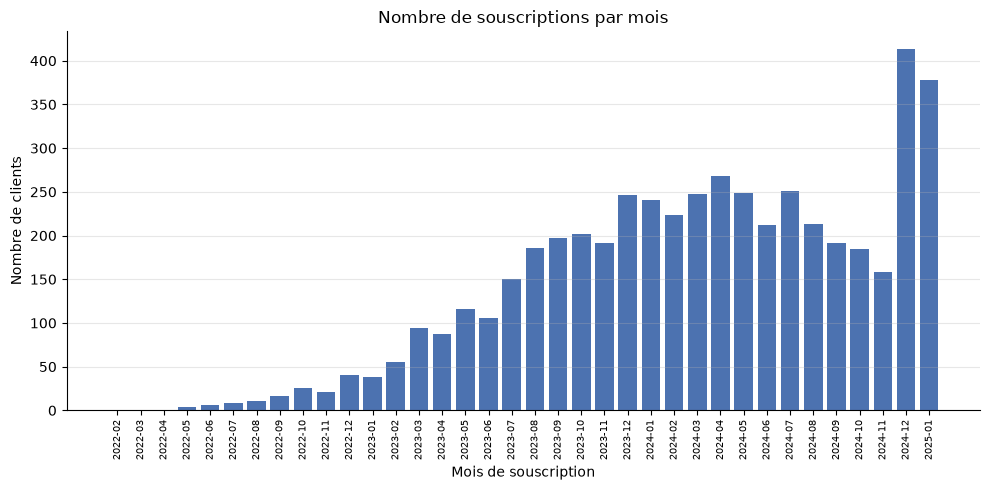

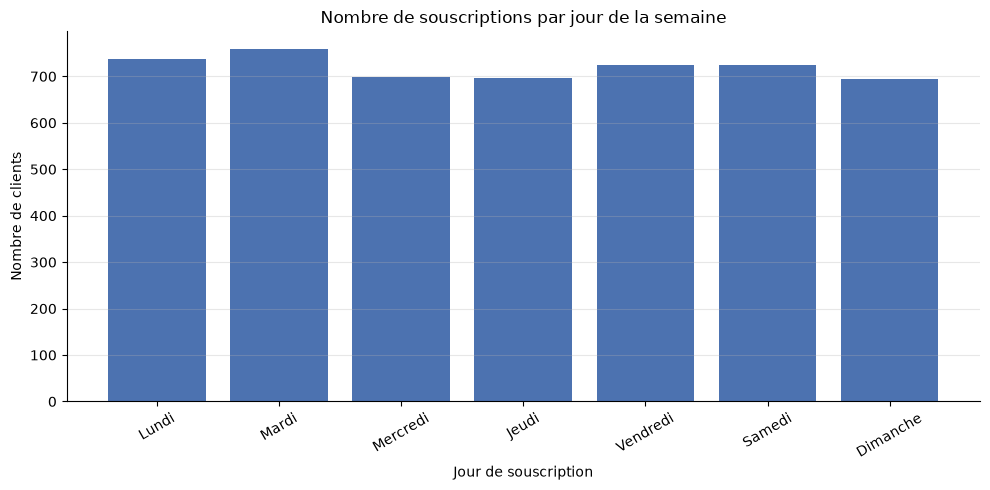

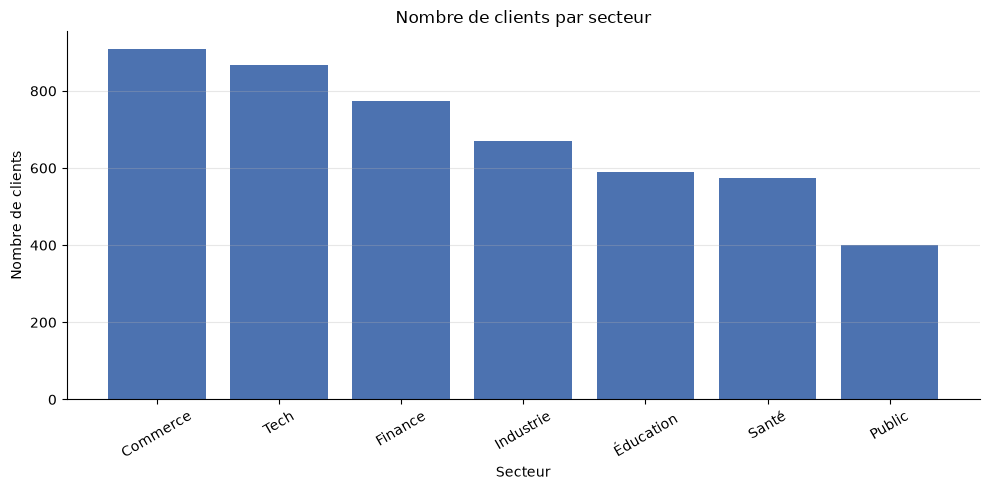

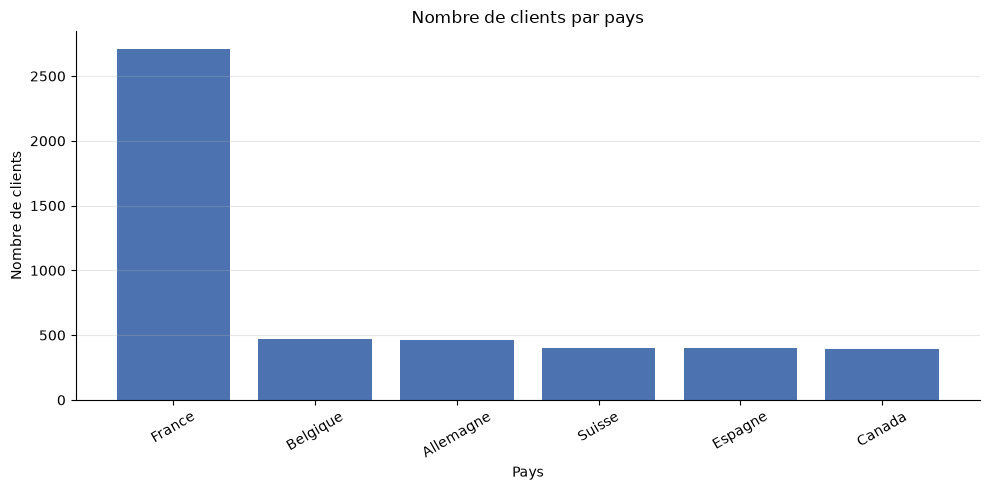

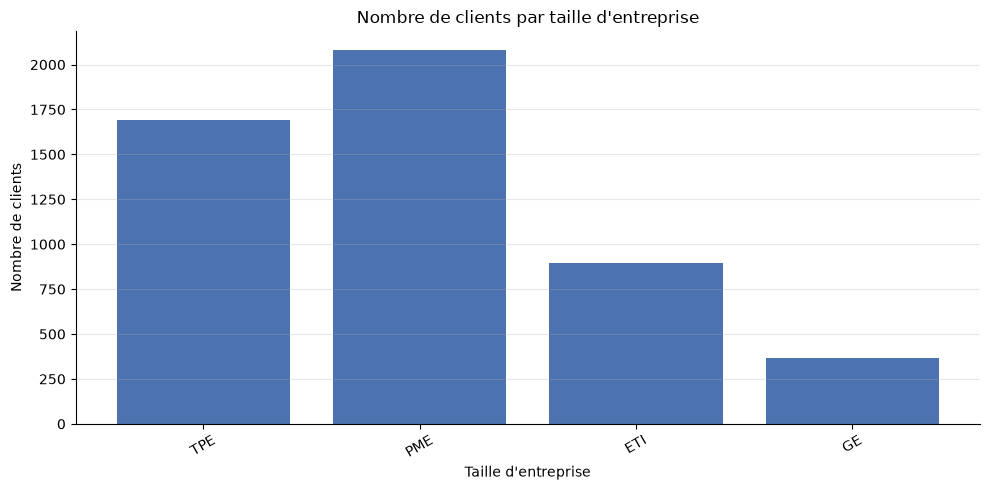

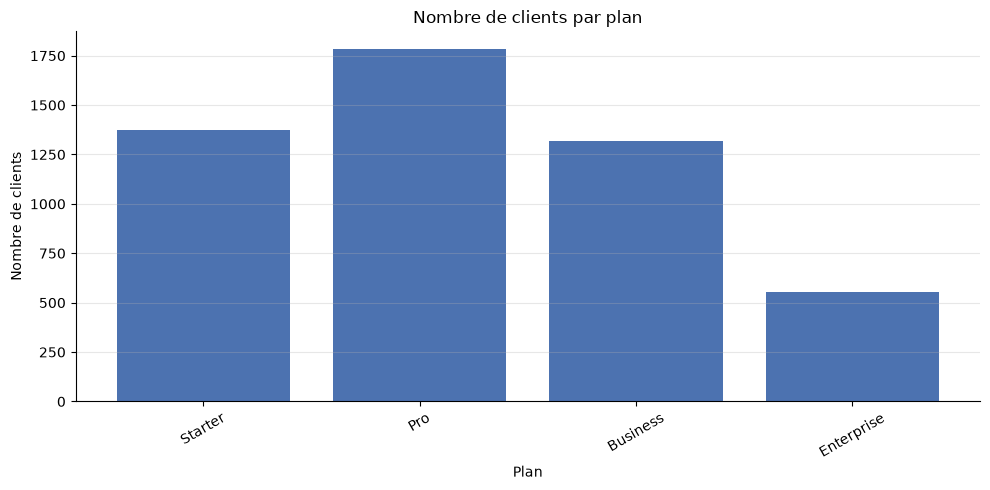

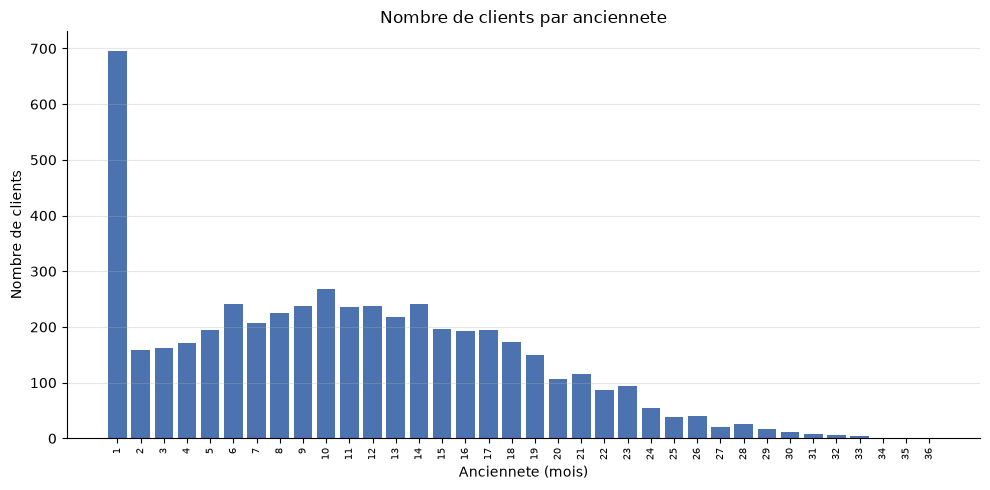

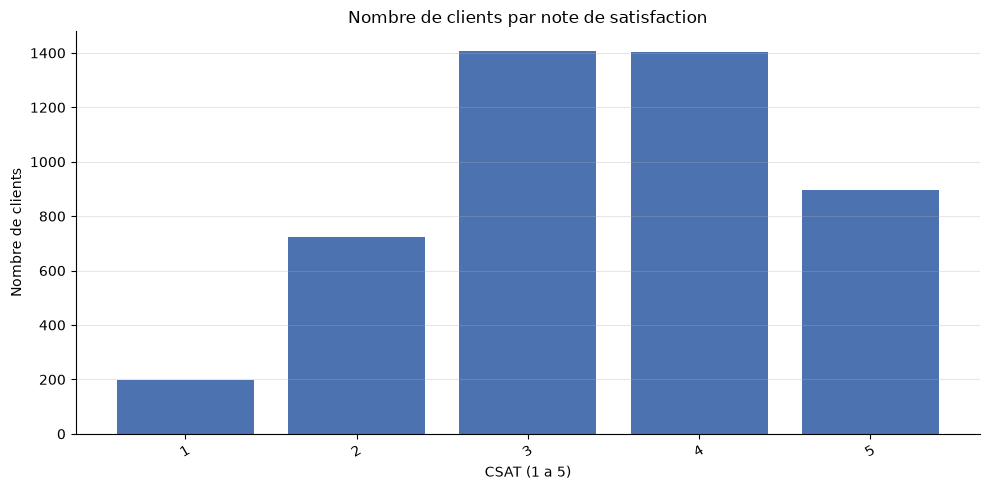

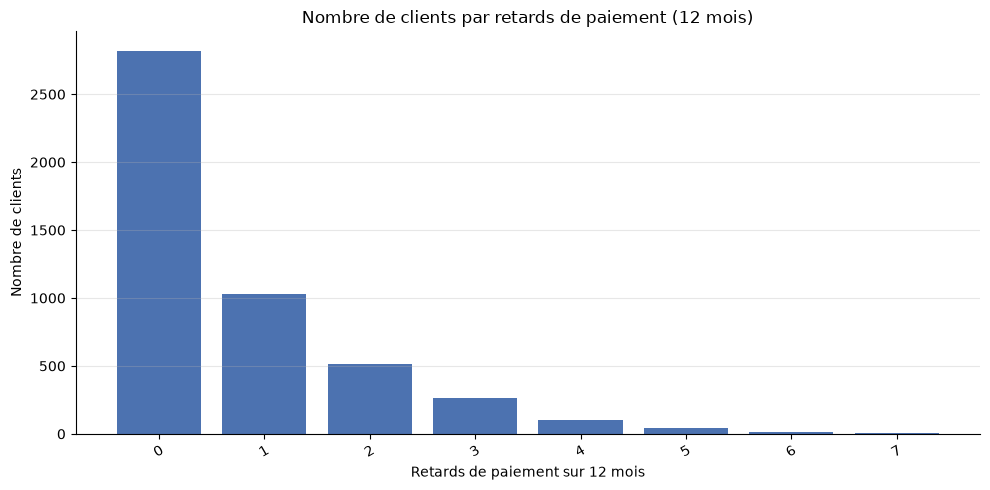

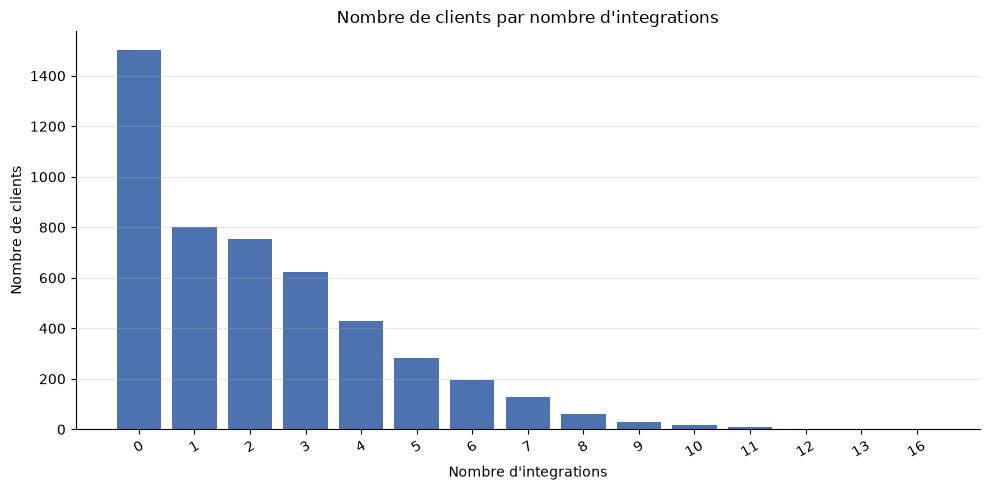

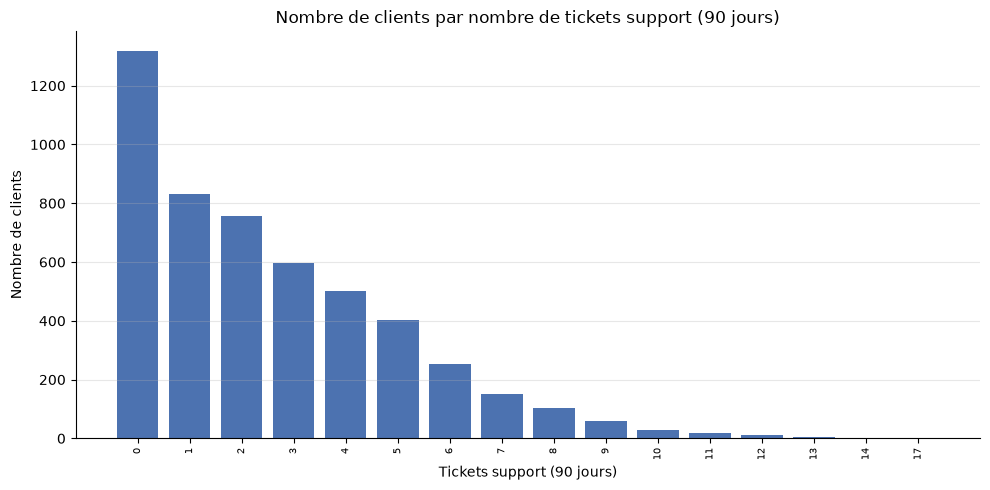

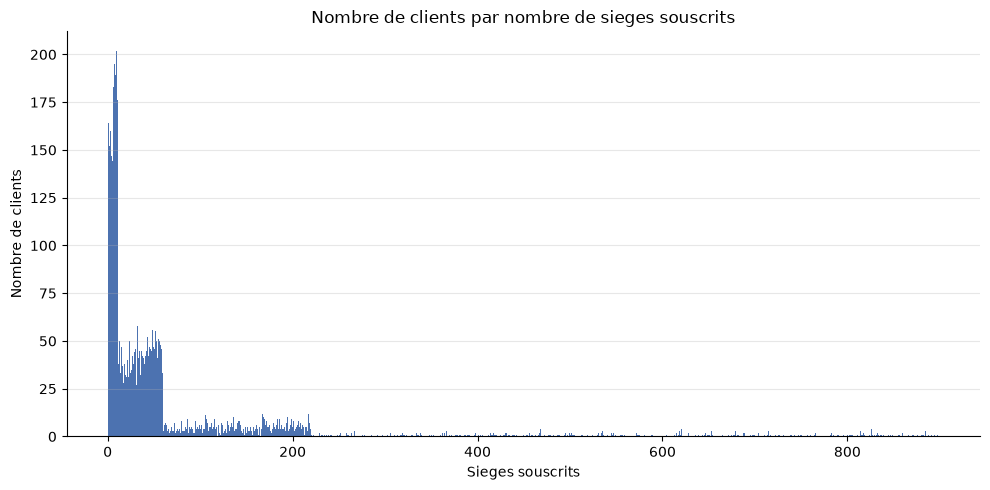

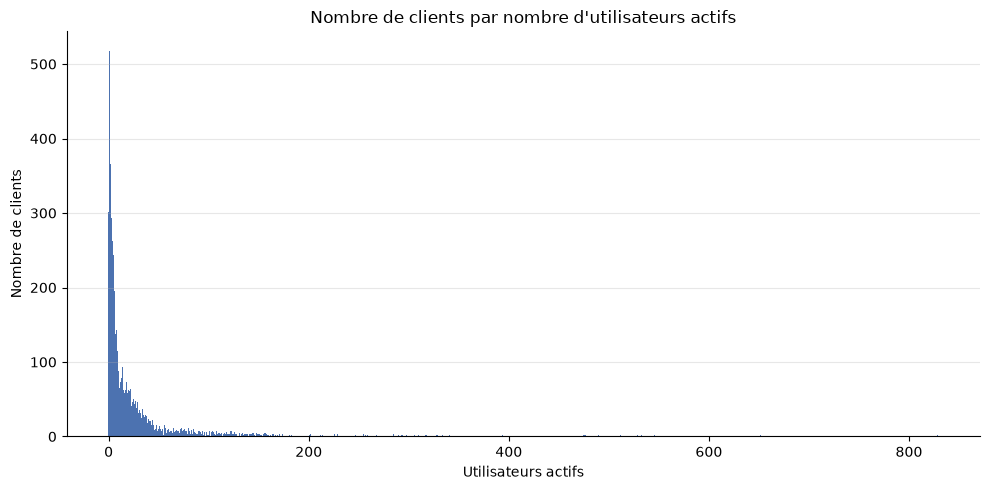

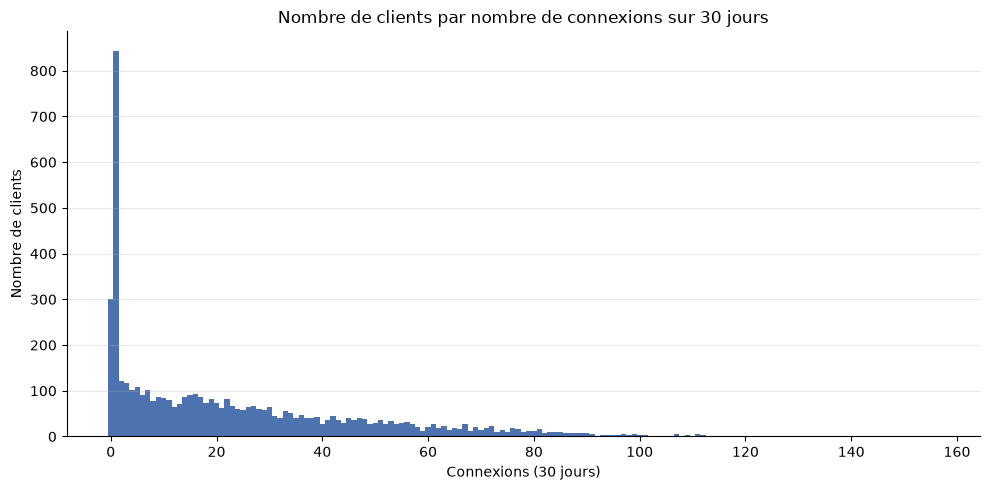

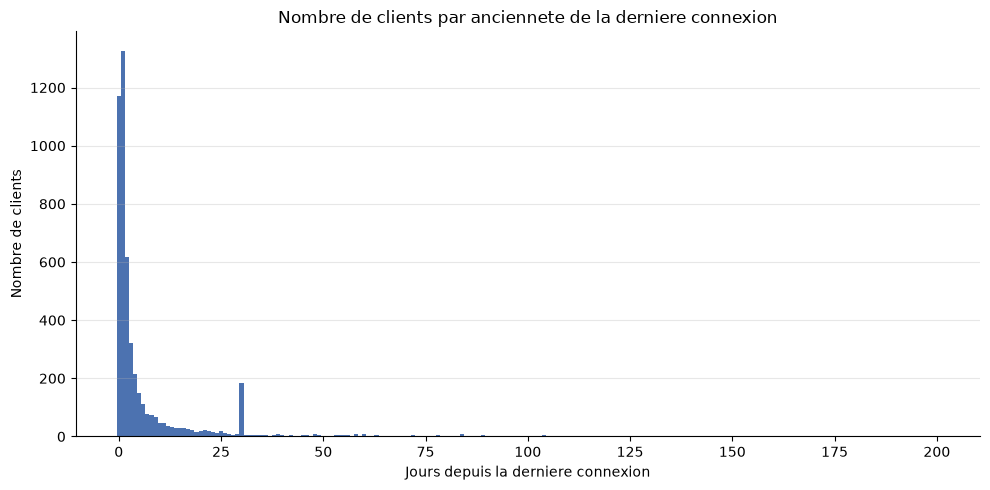

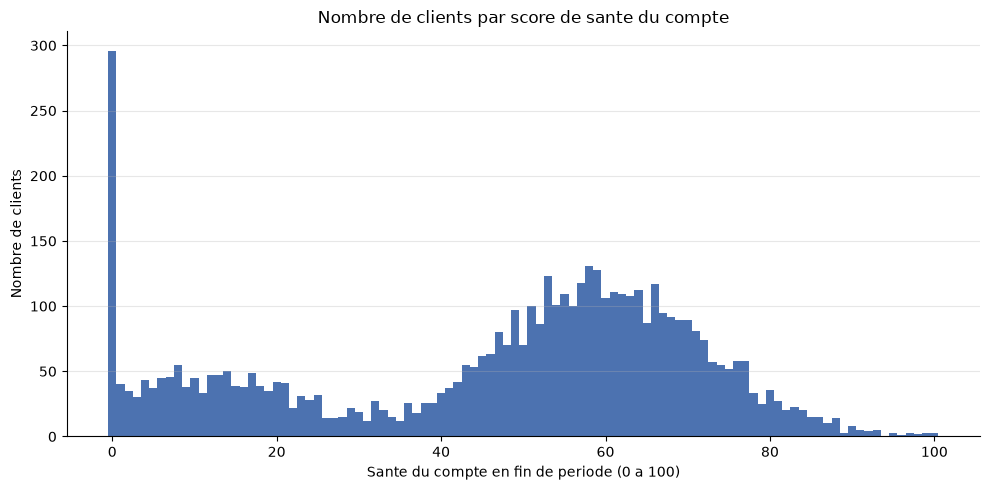

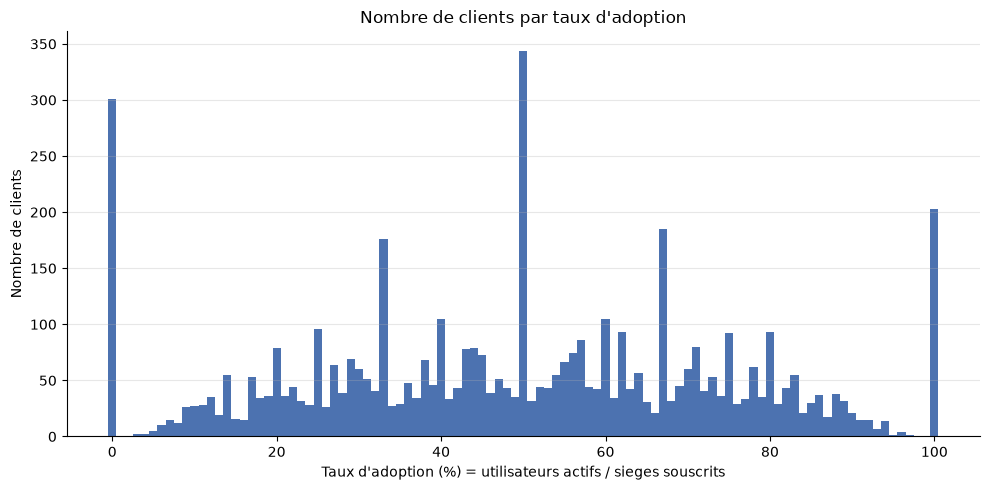

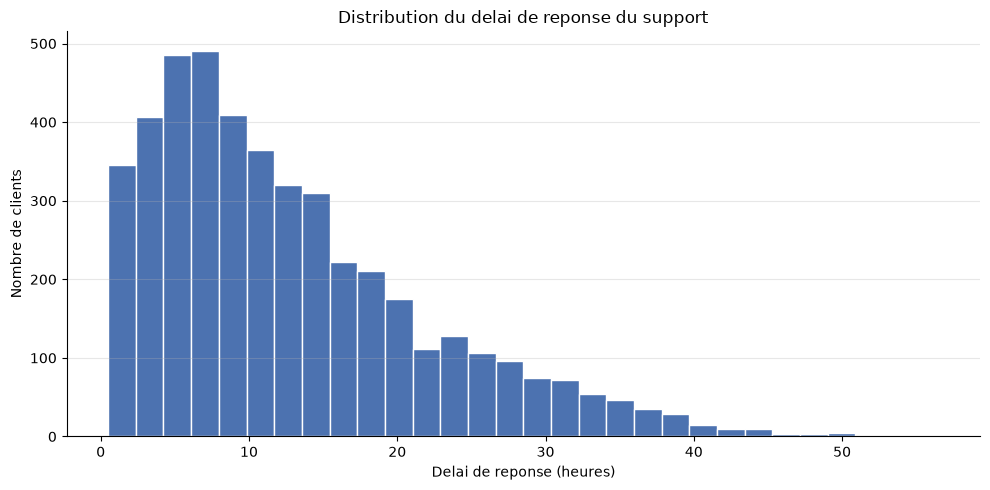

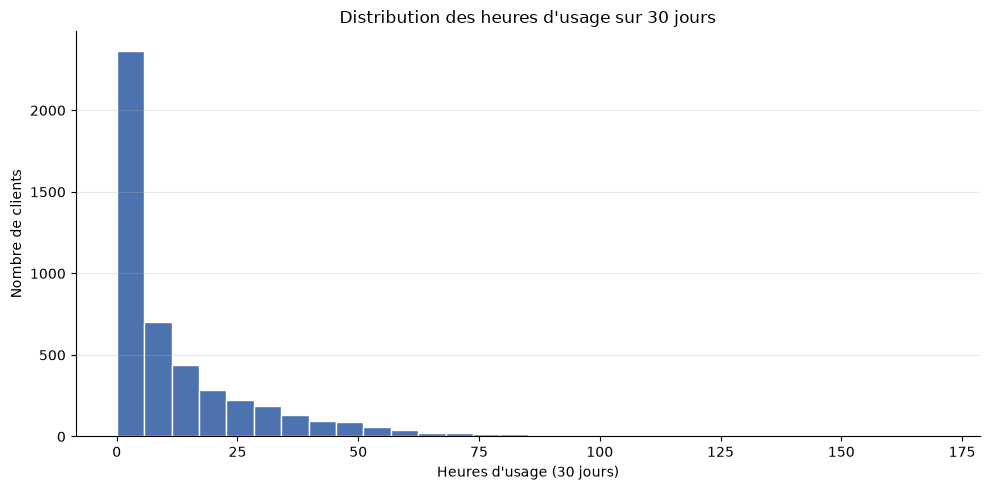

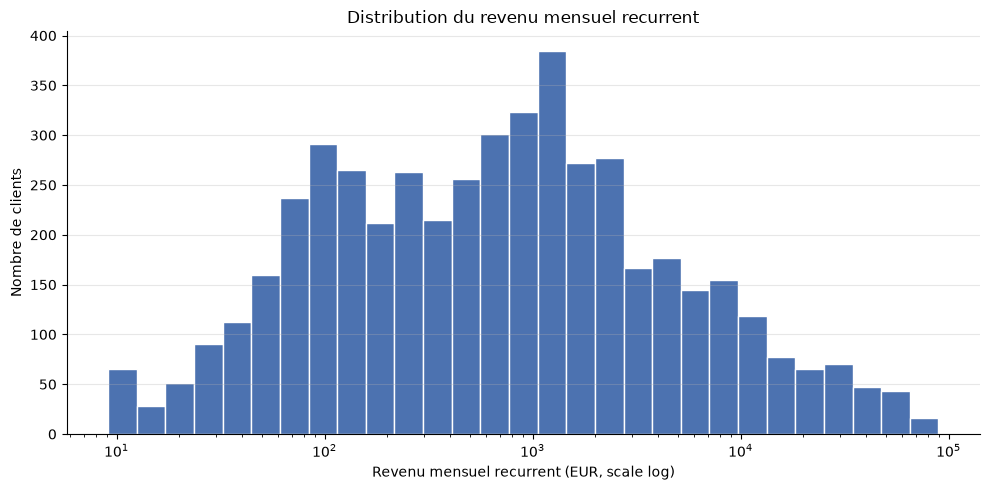

  export : src/visualization/graphs/date_souscription/histo_date_souscription.png
  export : src/visualization/graphs/jour_souscription/histo_jour_souscription.png
  export : src/visualization/graphs/secteur/histo_secteur.png
  export : src/visualization/graphs/pays/histo_pays.png
  export : src/visualization/graphs/taille_entreprise/histo_taille_entreprise.png
  export : src/visualization/graphs/plan/histo_plan.png
  export : src/visualization/graphs/anciennete_mois/histo_anciennete_mois.png
  export : src/visualization/graphs/csat/histo_csat.png
  export : src/visualization/graphs/retards_paiement_12m/histo_retards_paiement_12m.png
  export : src/visualization/graphs/nb_integrations/histo_nb_integrations.png
  export : src/visualization/graphs/tickets_support_90j/histo_tickets_support_90j.png
  export : src/visualization/graphs/sieges_souscrits/histo_sieges_souscrits.png
  export : src/visualization/graphs/utilisateurs_actifs/histo_utilisateurs_actifs.png
  export : src/visualization

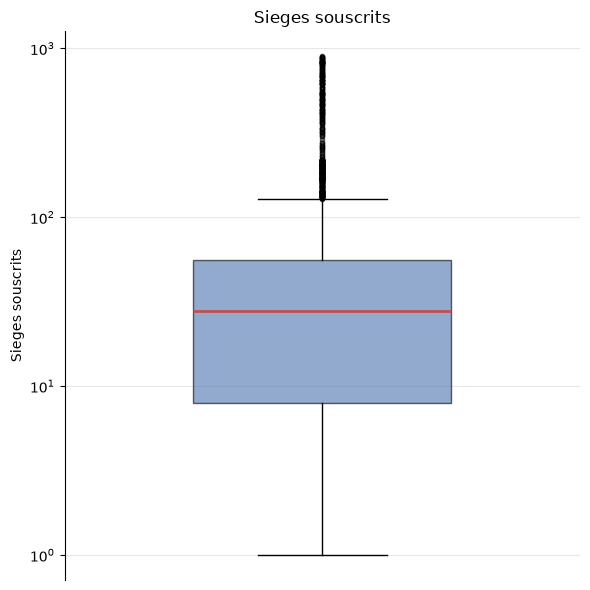

  sieges_souscrits                795 points hors moustaches (log)


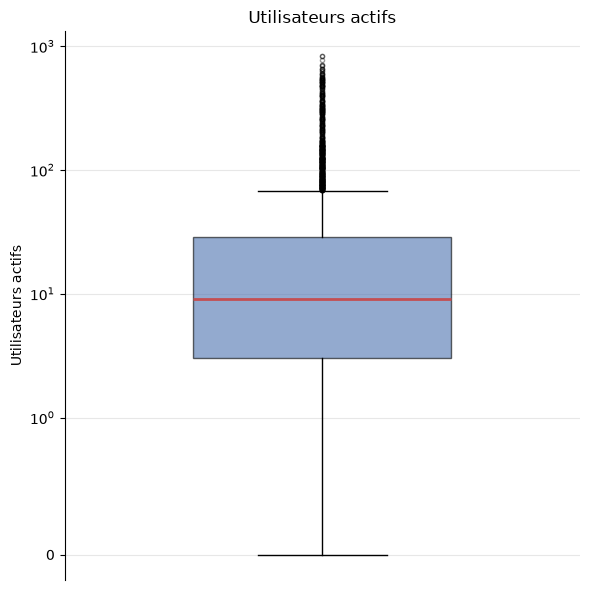

  utilisateurs_actifs             633 points hors moustaches (log)


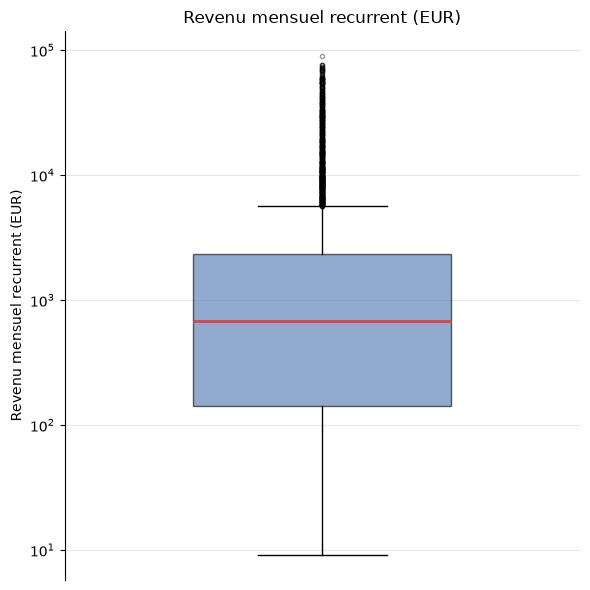

  revenu_mensuel_recurrent_eur    689 points hors moustaches (log)


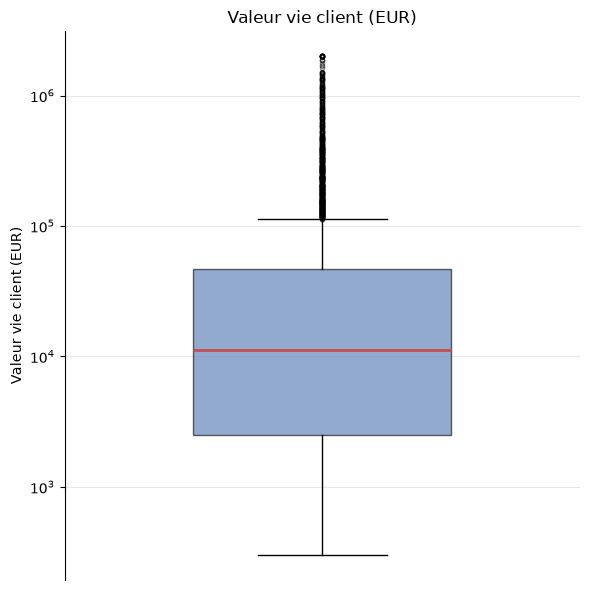

  valeur_vie_client_eur           719 points hors moustaches (log)


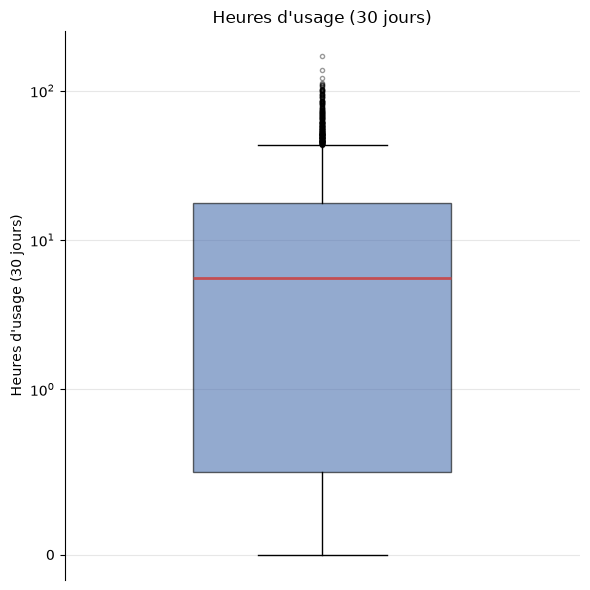

  heures_usage_30j                321 points hors moustaches (log)


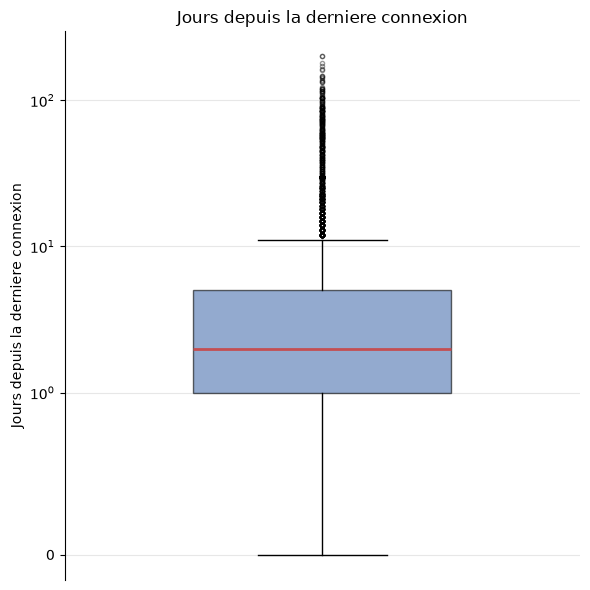

  derniere_connexion_jours        806 points hors moustaches (log)


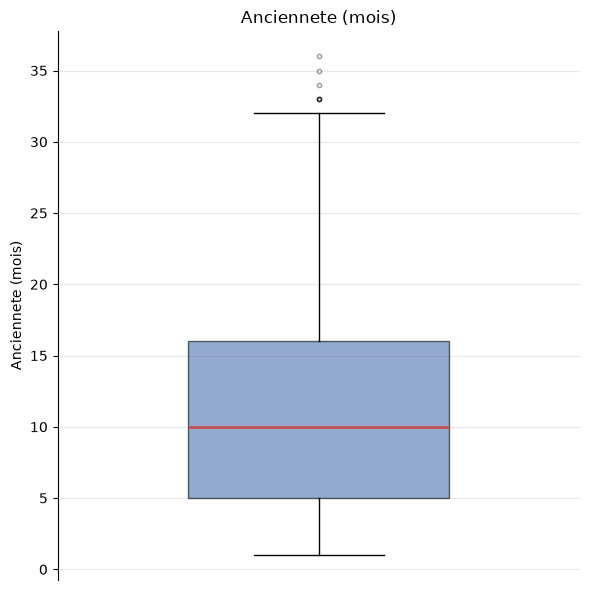

  anciennete_mois                   7 points hors moustaches (lineaire)


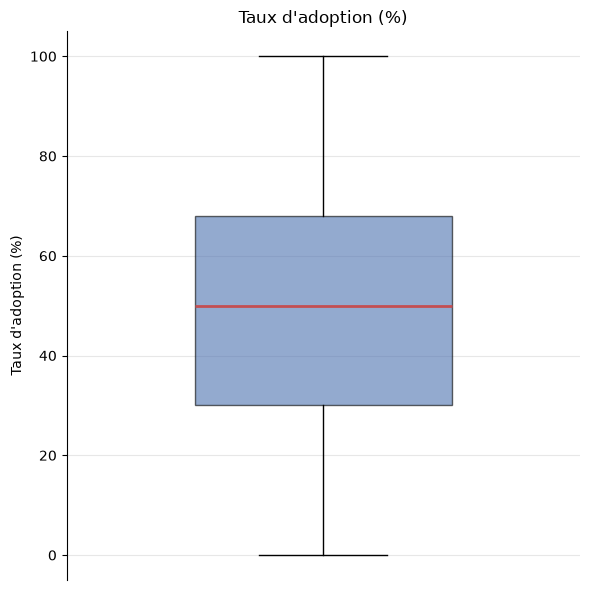

  taux_adoption_pct                 0 points hors moustaches (lineaire)


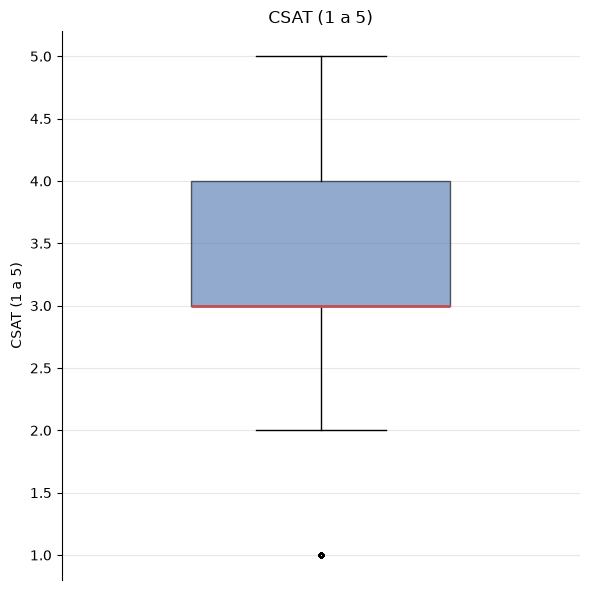

  csat                            197 points hors moustaches (lineaire)


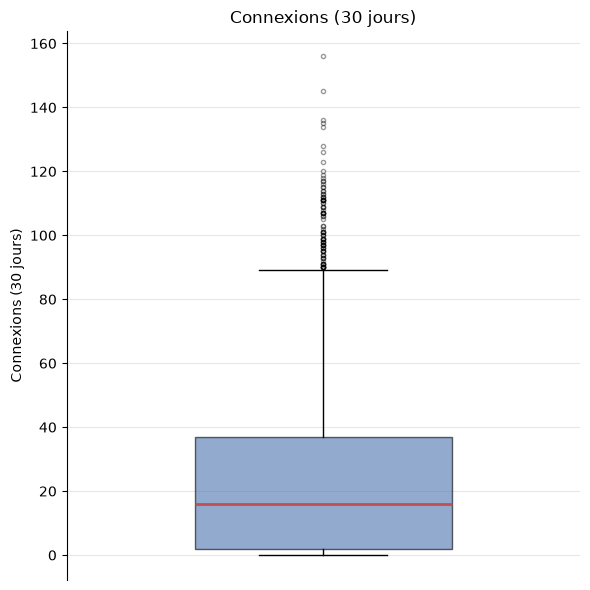

  connexions_30j                   93 points hors moustaches (lineaire)


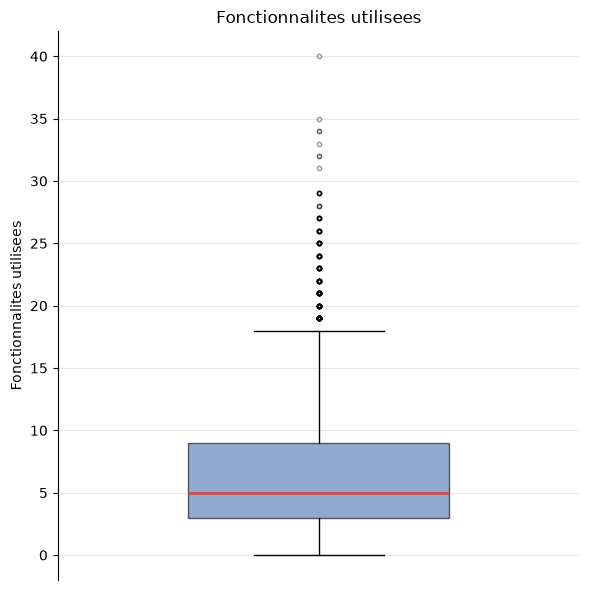

  fonctionnalites_utilisees       185 points hors moustaches (lineaire)


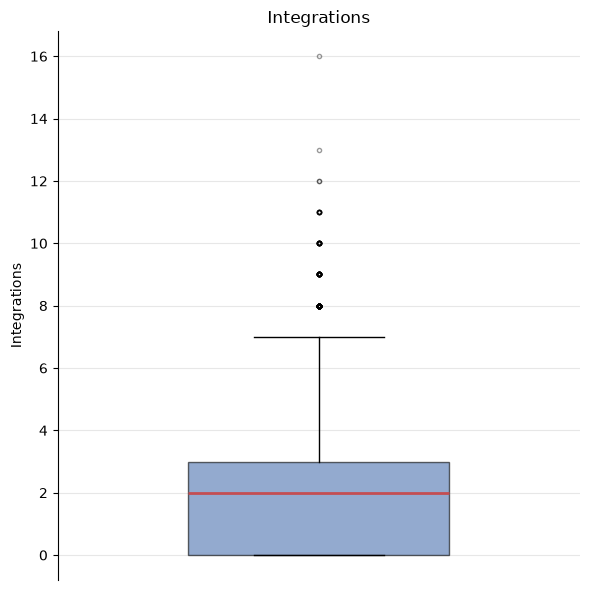

  nb_integrations                 117 points hors moustaches (lineaire)


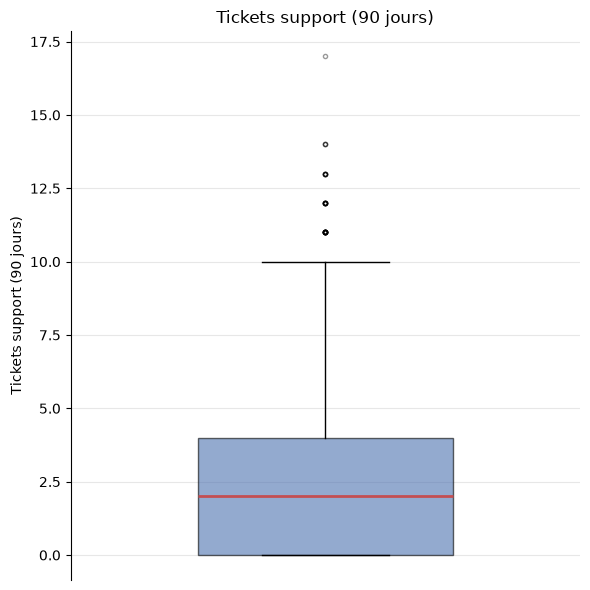

  tickets_support_90j              37 points hors moustaches (lineaire)


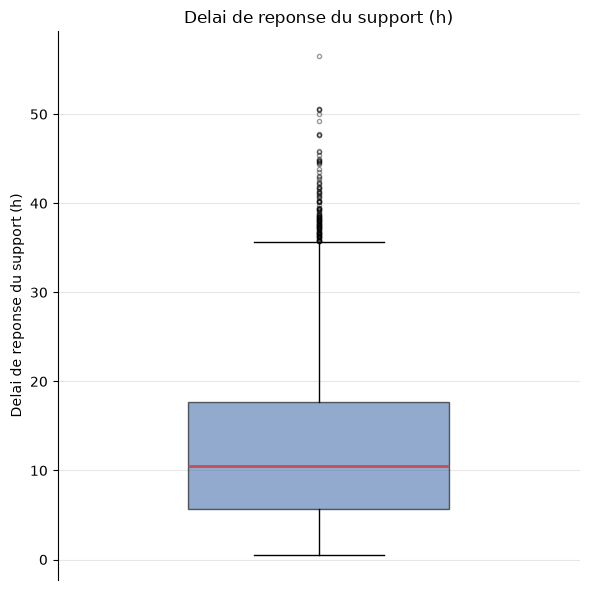

  delai_reponse_support_h         114 points hors moustaches (lineaire)


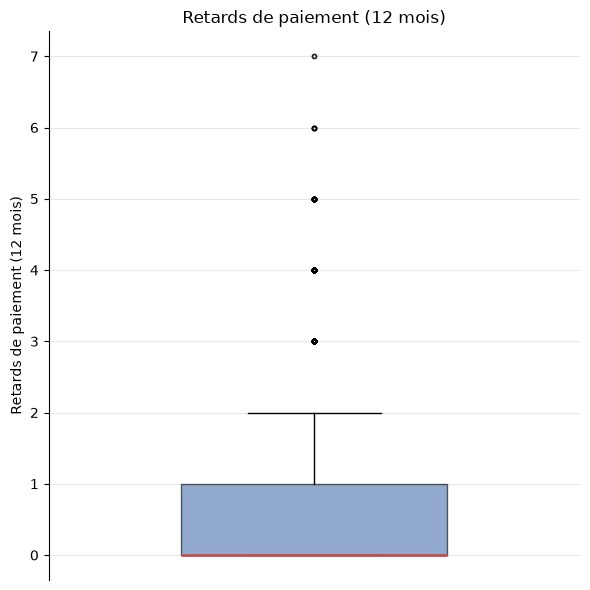

  retards_paiement_12m            422 points hors moustaches (lineaire)


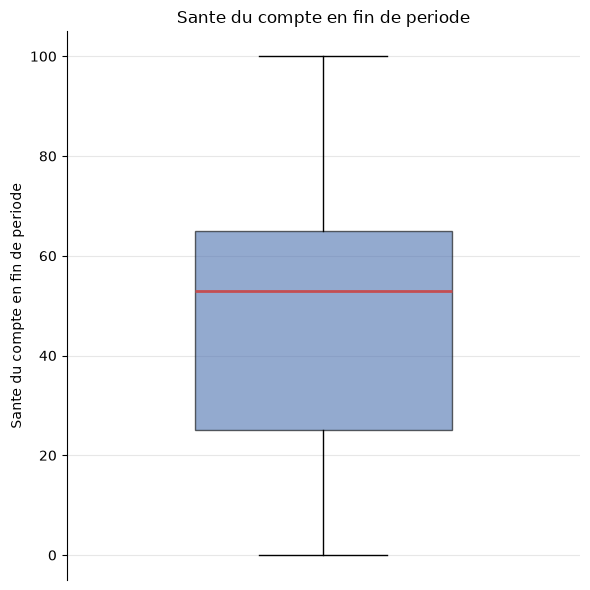

  sante_compte_fin_periode          0 points hors moustaches (lineaire)

BOITES A MOUSTACHES GROUPEES
churn_saas_complet.csv : 5035 lignes lues


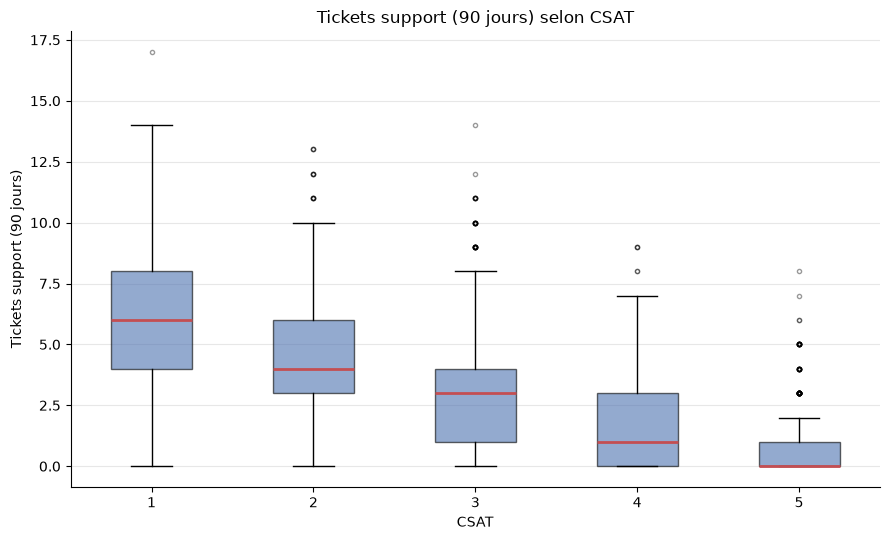

  tickets_support_90j        par csat | correlation -0.576 | medianes 1:6 2:4 3:3 4:1 5:0


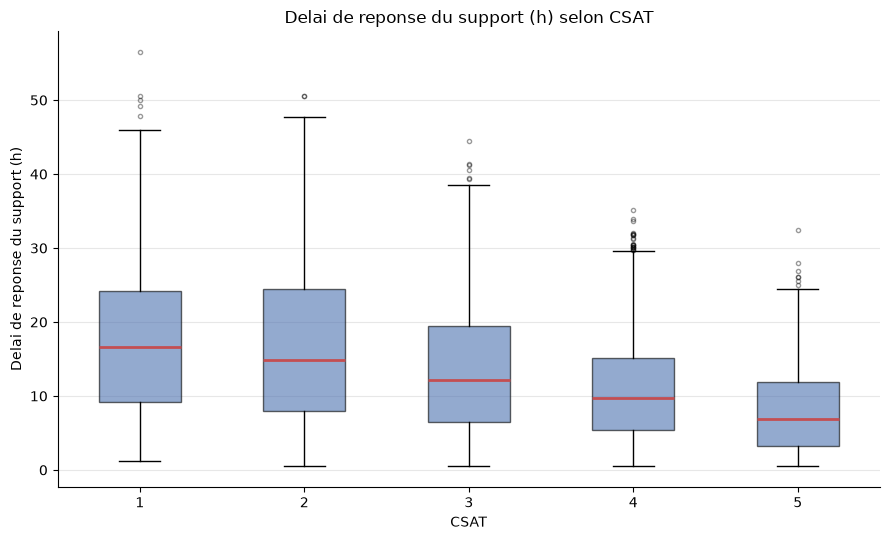

  delai_reponse_support_h    par csat | correlation -0.342 | medianes 1:16.6 2:14.9 3:12.2 4:9.7 5:6.9

TAUX DE CHURN PAR TRANCHE
churn_saas_complet.csv : 5035 lignes lues


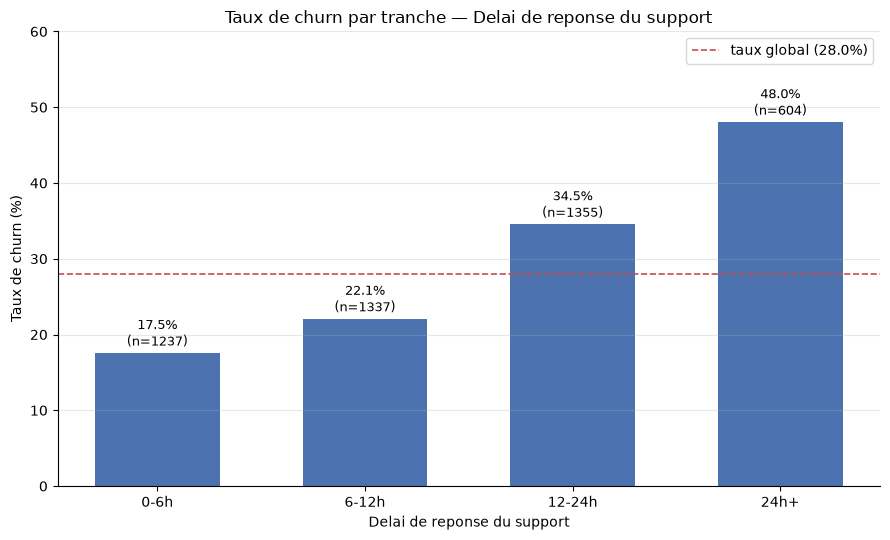

  delai_reponse_support_h    0-6h:17.5%(n=1237) 6-12h:22.1%(n=1337) 12-24h:34.5%(n=1355) 24h+:48.0%(n=604)

39 graphiques generes


In [4]:
import sys

sys.path.insert(0, "src")  # src/visualization n'est pas un package installe
from visualization.scripts.plot_all import plot_all

graphiques = plot_all()

## 🥉 2. Ingestion — couche bronze

Les trois CSV de `docs/` sont copiés **tels quels** dans le schéma `bronze` :
toutes les colonnes métier en `TEXT`, aucune conversion ni nettoyage. Chaque ligne
conserve son origine (`_source_file`, `_source_line`, `_ingested_at`).

Les tables sont vidées puis rechargées : relancer la cellule ne crée pas de
doublons. Le log compare les lignes lues dans le CSV à celles réellement insérées
en base, et signale tout écart.

In [ ]:
from ml_churn.ingestion.scripts.ingest_bronze import ingest_bronze

lignes_bronze = ingest_bronze()

## 🥈 3. Ingestion — couche silver

`bronze.churn_saas_complet_bronze` → `silver.churn_saas_silver`, en onze actions
successives :

1. **Déduplication** sur `client_id`
2. **Standardisation** de huit colonnes : dates ramenées au format `AAAA-MM-JJ`,
   pays en codes ISO, plans en `PRO`/`BUS`/`STR`/`ENT`, casse et espaces harmonisés
3. **Règles métier** : toute ligne hors bornes est supprimée
4. **Typage** : `date`, `integer` et `numeric` selon la colonne

In [3]:
from ml_churn.ingestion.scripts.ingest_silver import ingest_silver

lignes_silver = ingest_silver()

bronze.catalogue_bronze : 4 lignes lues

[STANDARDISATION PLAN] : 4 valeurs -> 4 valeurs

[TYPAGE CATALOGUE] : 4 valeurs -> 4 valeurs

silver.catalogue_silver : 4 lignes inserees

bronze.churn_saas_complet_bronze : 5035 lignes lues

[DEDUPLICATION CLIENT_ID] : 5035 lignes -> 5000 lignes

[STANDARDISATION DATE_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION JOUR_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION SECTEUR] : 4750 valeurs -> 4750 valeurs
[STANDARDISATION PAYS] : 4800 valeurs -> 4800 valeurs
[STANDARDISATION TAILLE_ENTREPRISE] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION PLAN] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION COULEUR_THEME_INTERFACE] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION GROUPE_EXPERIMENTATION] : 5000 valeurs -> 5000 valeurs

[DERIVATION POLARITE_CSM] : 2227 valeurs -> 5000 valeurs (ABSENT 2773, NEUTRE 947, ALERTE 873, POSITIF 407)

[REGLE CLIENT_ID] : 5000 lignes -> 5000 lignes (0)
[REGLE ANCIENNETE_MOIS] : 5000 lignes -

## 🥇 4. Ingestion — couche gold

`silver` → `gold`, pour les deux tables : `catalogue_gold` et
`churn_saas_gold`. Les tables reprennent **la structure de silver à
l'identique** (mêmes colonnes, mêmes types) — les définitions sont partagées
via les mixins de `models/colonnes.py`, il n'y a donc pas deux schémas à
maintenir.

Gold est la couche stable sur laquelle s'appuient l'analyse et la
modélisation, sans dépendre des retraitements successifs de silver.

In [1]:
from ml_churn.ingestion.scripts.ingest_gold import ingest_gold

lignes_gold = ingest_gold()

silver.catalogue_silver : 4 lignes lues
gold.catalogue_gold : 4 lignes inserees

silver.churn_saas_silver : 5000 lignes lues
colonnes derivees : inactivite_relative, taux_fonctionnalites, inactif_30j (435 clients), niveau_anciennete (ETABLI 2011, ANCIEN 1984, RECENT 1005)
encodage one-hot : 10 colonnes categorielles -> 47 colonnes binaires
gold.churn_saas_gold : 5000 lignes inserees

TOTAL :
      - gold.catalogue_gold : 4 lignes
      - gold.churn_saas_gold : 5000 lignes


## 5. Déséquilibre de la cible

Effectifs de chaque valeur de `churn` et taux de résiliation, lus dans
`gold.churn_saas_gold`. Le code est dans `src/ml_churn/training/scripts/`.

Ce déséquilibre conditionne le choix des métriques : un modèle qui prédirait
« personne ne résilie » aurait déjà une exactitude égale à la part de clients
actifs.

In [1]:
from ml_churn.training.scripts.analyze_target import analyze_target

repartition_cible = analyze_target()

churn = 0 (actif   ) : 3600 clients (72.00%)
churn = 1 (resilie ) : 1400 clients (28.00%)

taux de churn : 28.00% sur 5000 clients
